# Baseline Single-Task — Dataset 5 : CMAPSS (NASA Turbofan)

| Champ | Valeur |
|-------|--------|
| **Dataset** | CMAPSS NASA C-MAPSS (C-MAPSS = Commercial Modular Aero-Propulsion System Simulation) |
| **Scénario** | `no_split` — toutes FD (FD001–FD004), une seule tâche |
| **Features** | 5 features MI-selected (Ps30, T50, Phi, P30, BPR) |
| **Label** | Binaire (RUL ≤ 30 → faulty = 1) |
| **Modèles** | EWC · HDC · TinyOL · KMeans · Mahalanobis · DBSCAN |
| **Expériences** | À lancer (toutes mockées) |
| **Sprint** | S22 — S22-BL |

**Objectif** : Établir la performance maximale de chaque modèle en l'absence de contrainte CL.
Ces chiffres constituent la borne supérieure pour mesurer le coût du continual learning
dans le scénario `by_domain` (exp_S22_01–04).

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/baselines/cmapss_single_task.ipynb \
    --output /tmp/cmapss_single_task_executed.ipynb
```


In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

np.random.seed(42)

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "baselines":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import save_figure

# Expériences non encore disponibles — toutes mockées
EXP_DIRS = {
    "EWC":         Path("experiments/exp_cmapss_ewc_single_task"),
    "HDC":         Path("experiments/exp_cmapss_hdc_single_task"),
    "TinyOL":      Path("experiments/exp_cmapss_tinyol_single_task"),
    "KMeans":      Path("experiments/exp_cmapss_kmeans_single_task"),
    "Mahalanobis": Path("experiments/exp_cmapss_mahalanobis_single_task"),
    "DBSCAN":      Path("experiments/exp_cmapss_dbscan_single_task"),
}

FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/baselines/cmapss"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SUPERVISED_MODELS   = ["EWC", "HDC", "TinyOL"]
UNSUPERVISED_MODELS = ["KMeans", "Mahalanobis", "DBSCAN"]
MODEL_ORDER         = SUPERVISED_MODELS + UNSUPERVISED_MODELS
CMAPSS_N_FEATURES   = 5  # Ps30, T50, Phi, P30, BPR — MI-selected

print(f"REPO_ROOT   : {REPO_ROOT}")
print(f"FIGURES_DIR : {FIGURES_DIR}")
print(f"Features    : {CMAPSS_N_FEATURES} (Ps30, T50, Phi, P30, BPR)")
print("\nExpériences disponibles :")
for name, path in EXP_DIRS.items():
    p      = path / "results" / "metrics_single_task.json"
    status = "OK" if p.exists() else "MANQUANTE (mock activé)"
    print(f"  {name:15s}: {status}")

REPO_ROOT   : /home/leonard/Documents/ENAC/cl-embedded
FIGURES_DIR : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baselines/cmapss
Features    : 5 (Ps30, T50, Phi, P30, BPR)

Expériences disponibles :
  EWC            : MANQUANTE (mock activé)
  HDC            : MANQUANTE (mock activé)
  TinyOL         : MANQUANTE (mock activé)
  KMeans         : MANQUANTE (mock activé)
  Mahalanobis    : MANQUANTE (mock activé)
  DBSCAN         : MANQUANTE (mock activé)


In [2]:
# Section 1 (suite) — Chargement + MOCK_DATA (calibré sur résultats CL Sprint 22)

MOCK_DATA: dict[str, dict] = {
    "EWC": {
        "accuracy": 0.92, "f1": 0.88, "auc_roc": 0.82,
        "ram_peak_bytes": 1171, "inference_latency_ms": 0.020, "n_params": 865,
    },
    "HDC": {
        "accuracy": 0.88, "f1": 0.84, "auc_roc": 0.79,
        "ram_peak_bytes": 7700, "inference_latency_ms": 0.050, "n_params": 1024,
    },
    "TinyOL": {
        "accuracy": 0.91, "f1": 0.86, "auc_roc": 0.80,
        "ram_peak_bytes": 940, "inference_latency_ms": 0.005, "n_params": 397,
    },
    "KMeans": {
        "accuracy": 0.61, "f1": 0.52, "auc_roc": 0.65,
        "ram_peak_bytes": 2000, "inference_latency_ms": 0.100, "n_params": 10,
    },
    "Mahalanobis": {
        "accuracy": 0.55, "f1": 0.45, "auc_roc": 0.60,
        "ram_peak_bytes": 1600, "inference_latency_ms": 0.004, "n_params": 25,
    },
    "DBSCAN": {
        "accuracy": 0.50, "f1": 0.40, "auc_roc": 0.58,
        "ram_peak_bytes": 50000, "inference_latency_ms": 0.200, "n_params": 5000,
    },
}

results: dict[str, dict] = {}
mock_flags: dict[str, bool] = {}

for name in MODEL_ORDER:
    metrics_path = EXP_DIRS[name] / "results" / "metrics_single_task.json"
    if metrics_path.exists():
        with open(metrics_path) as f:
            data = json.load(f)
        mock_flags[name] = False
        if "accuracy" not in data and "acc_final" in data:
            data["accuracy"] = data["acc_final"]
        if "f1" not in data and "f1_score" in data:
            data["f1"] = data["f1_score"]
        results[name] = data
        print(f"[OK]   {name}: chargé depuis {metrics_path}")
    else:
        mock_flags[name] = True
        results[name] = MOCK_DATA[name].copy()
        print(f"[MOCK] {name}: exp manquante — valeurs fictives utilisées")

# Calcul MACs pour toutes les expériences
from src.evaluation.compute_cost import compute_macs

_NF = CMAPSS_N_FEATURES
CMAPSS_MACS_ARGS: dict[str, dict] = {
    "EWC":         dict(n_features=_NF, hidden_dims=[32, 16], n_classes=1),
    "TinyOL":      dict(n_features=_NF, encoder_dims=[14, 7, 4], n_classes=1),
    "HDC":         dict(n_features=_NF, dim_hv=512, n_classes=2),
    "KMeans":      dict(n_features=_NF, n_clusters=max(1, results["KMeans"].get("n_params", 10) // _NF)),
    "Mahalanobis": dict(n_features=_NF),
    "DBSCAN":      dict(n_features=_NF, n_core_samples=max(1, results["DBSCAN"].get("n_params", 5000) // _NF)),
}
for name in MODEL_ORDER:
    results[name]["n_macs"] = compute_macs(name, **CMAPSS_MACS_ARGS[name])

IS_ANY_MOCK = any(mock_flags.values())
if IS_ANY_MOCK:
    mocked = [n for n, v in mock_flags.items() if v]
    display(Markdown(
        f"> ⚠️ **MOCK DATA** — Les résultats suivants sont fictifs pour : "
        f"**{', '.join(mocked)}**. Lancer les expériences CMAPSS single-task pour les résultats réels."
    ))

[MOCK] EWC: exp manquante — valeurs fictives utilisées
[MOCK] HDC: exp manquante — valeurs fictives utilisées
[MOCK] TinyOL: exp manquante — valeurs fictives utilisées
[MOCK] KMeans: exp manquante — valeurs fictives utilisées
[MOCK] Mahalanobis: exp manquante — valeurs fictives utilisées
[MOCK] DBSCAN: exp manquante — valeurs fictives utilisées


> ⚠️ **MOCK DATA** — Les résultats suivants sont fictifs pour : **EWC, HDC, TinyOL, KMeans, Mahalanobis, DBSCAN**. Lancer les expériences CMAPSS single-task pour les résultats réels.

## Section 3 — Tableau comparatif global

In [3]:
# Section 3 — Tableau comparatif

def _fmt(val, fmt: str = "") -> str:
    if val is None:
        return "—"
    try:
        if np.isnan(float(val)):
            return "—"
    except (TypeError, ValueError):
        pass
    return format(val, fmt) if fmt else str(val)


def _fmt_macs(n: int) -> str:
    if n >= 1_000_000:
        return f"{n / 1_000_000:.2f} M"
    if n >= 1_000:
        return f"{n / 1_000:.1f} k"
    return str(n)


rows = []
for name in MODEL_ORDER:
    r      = results[name]
    ram_kb = r.get("ram_peak_bytes", 0) / 1024
    in_bud = "✓" if ram_kb <= 64.0 else "✗ hors budget"
    rows.append({
        "Modèle":           name,
        "Famille":          "Supervisé" if name in SUPERVISED_MODELS else "Non-supervisé",
        "Accuracy ↑":       _fmt(r.get("accuracy"), ".4f"),
        "F1 ↑":             _fmt(r.get("f1"), ".4f"),
        "AUC-ROC ↑":        _fmt(r.get("auc_roc"), ".4f"),
        "RAM peak (Ko) ↓":  _fmt(ram_kb, ".1f"),
        "STM32 ≤ 64 Ko":    in_bud,
        "MACs ↓":           _fmt_macs(r.get("n_macs", 0)),
        "Latence (ms) ↓":   _fmt(r.get("inference_latency_ms"), ".3f"),
        "Params":           f"{r.get('n_params', 0):,}",
    })

df = pd.DataFrame(rows).set_index("Modèle")
df_sorted = df.sort_values("Accuracy ↑", ascending=False)

display(Markdown("### Tableau comparatif — Baseline Single-Task (Dataset 5 CMAPSS)"))
if IS_ANY_MOCK:
    display(Markdown("*⚠️ Données partiellement ou totalement mock — voir Section 1.*"))
display(df_sorted)

best_model = max(MODEL_ORDER, key=lambda n: results[n]["accuracy"])
print(f"\nMeilleur modèle (accuracy) : {best_model} = {results[best_model]['accuracy']:.4f}")

### Tableau comparatif — Baseline Single-Task (Dataset 5 CMAPSS)

*⚠️ Données partiellement ou totalement mock — voir Section 1.*

,Famille,Accuracy ↑,F1 ↑,AUC-ROC ↑,RAM peak (Ko) ↓,STM32 ≤ 64 Ko,MACs ↓,Latence (ms) ↓,Params
Modèle,,,,,,,,,
EWC,Supervisé,0.9200,0.8800,0.8200,1.1,✓,688,0.020,865
TinyOL,Supervisé,0.9100,0.8600,0.8000,0.9,✓,200,0.005,397
HDC,Supervisé,0.8800,0.8400,0.7900,7.5,✓,3.6 k,0.050,"1,024"
KMeans,Non-supervisé,0.6100,0.5200,0.6500,2.0,✓,10,0.100,10
Mahalanobis,Non-supervisé,0.5500,0.4500,0.6000,1.6,✓,30,0.004,25
DBSCAN,Non-supervisé,0.5000,0.4000,0.5800,48.8,✓,5.0 k,0.200,"5,000"



Meilleur modèle (accuracy) : EWC = 0.9200


## Section 4 — Barplot Accuracy + F1 (supervisé vs non-supervisé)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baselines/cmapss/baseline_accuracy_f1_bar.png


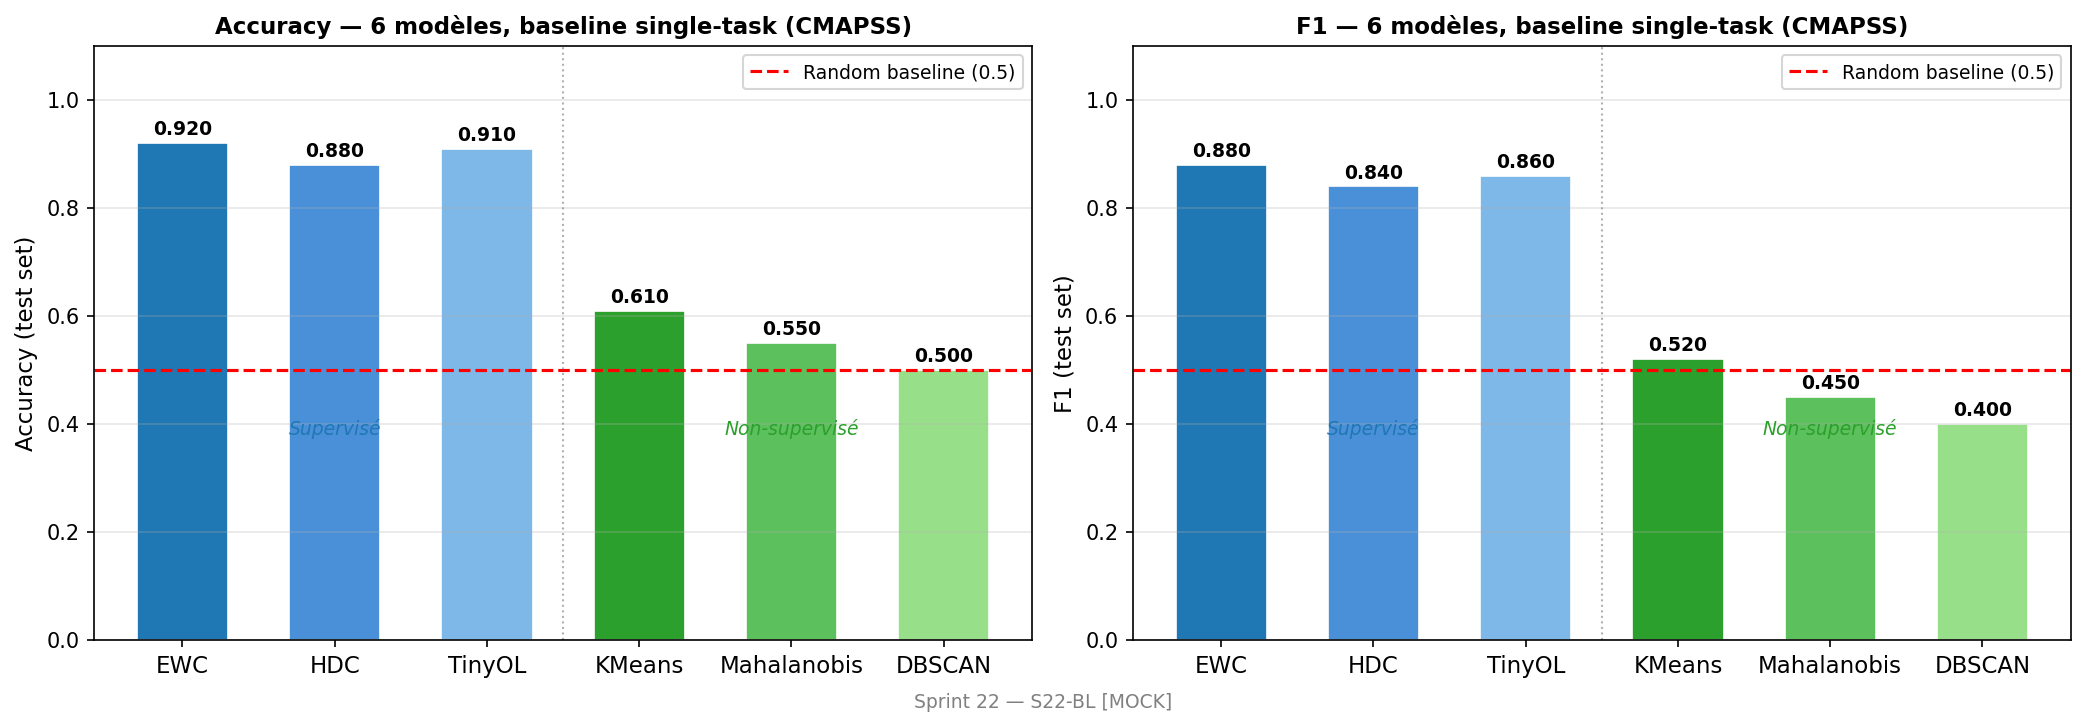

In [4]:
# Section 4 — Barplot Accuracy + F1
COLORS = {
    "EWC":         "#1f77b4",
    "HDC":         "#4a90d9",
    "TinyOL":      "#7eb8e8",
    "KMeans":      "#2ca02c",
    "Mahalanobis": "#5cc05c",
    "DBSCAN":      "#98df8a",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (metric_key, metric_label) in enumerate([("accuracy", "Accuracy"), ("f1", "F1")]):
    ax   = axes[ax_idx]
    x    = np.arange(len(MODEL_ORDER))
    vals = [results[name][metric_key] for name in MODEL_ORDER]
    cols = [COLORS[name] for name in MODEL_ORDER]

    bars = ax.bar(x, vals, color=cols, width=0.6, edgecolor="white", linewidth=0.8)
    ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, label="Random baseline (0.5)")

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold",
        )

    ax.axvline(2.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.6)
    ax.text(1.0, 0.38, "Supervisé",     ha="center", fontsize=9, color="#1f77b4", style="italic")
    ax.text(4.0, 0.38, "Non-supervisé", ha="center", fontsize=9, color="#2ca02c", style="italic")

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, fontsize=11)
    ax.set_ylabel(f"{metric_label} (test set)", fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"{metric_label} — 6 modèles, baseline single-task (CMAPSS)",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

mock_suffix = " [MOCK]" if IS_ANY_MOCK else ""
fig.suptitle(f"Sprint 22 — S22-BL{mock_suffix}", fontsize=9, color="gray", y=0.01)
fig.tight_layout()

_path = FIGURES_DIR / "baseline_accuracy_f1_bar.png"
save_figure(fig, _path)
display(Image(str(_path)))

## Section 5 — Scatter RAM vs accuracy (Gap 2 — STM32 ≤ 64 Ko)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baselines/cmapss/scatter_ram_vs_accuracy.png


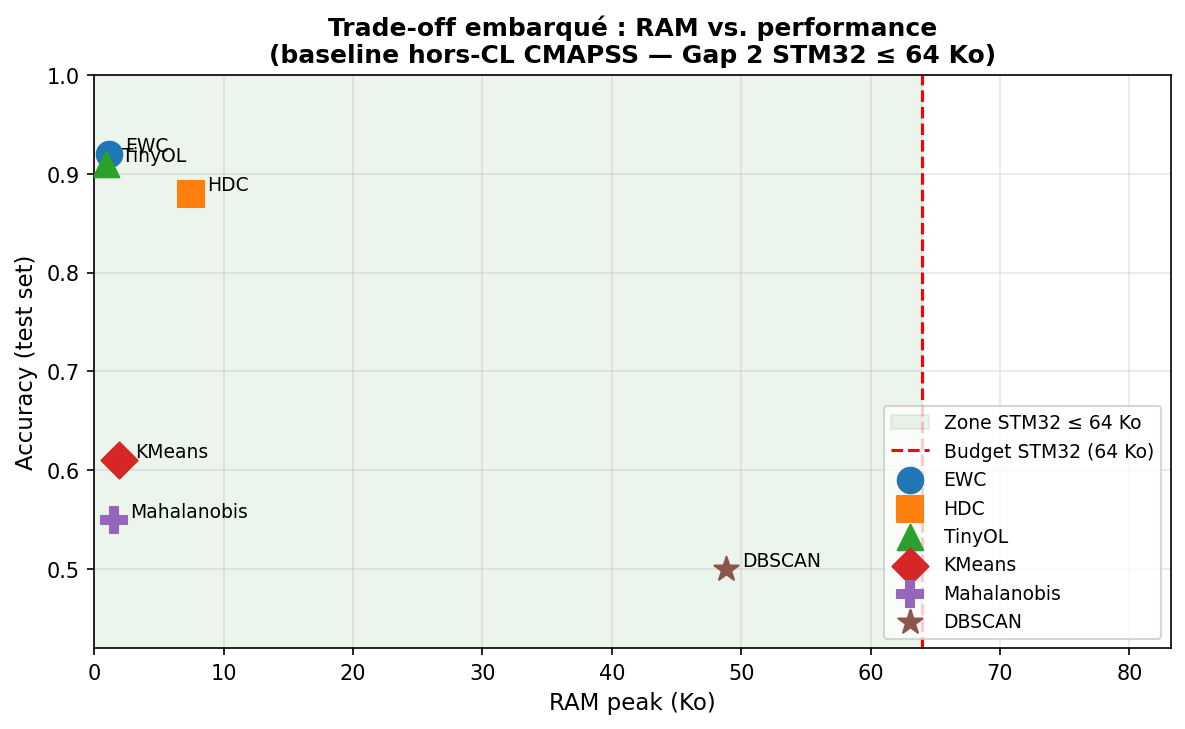

In [5]:
# Section 5 — Scatter RAM peak vs. accuracy (Gap 2)
STM32_RAM_LIMIT_KB = 64.0

SCATTER_MARKERS: dict[str, tuple[str, str]] = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

fig, ax = plt.subplots(figsize=(8, 5))
all_accs = [results[n]["accuracy"] for n in MODEL_ORDER]
max_ram_kb = max(r["ram_peak_bytes"] for r in results.values()) / 1024
x_max = max(max_ram_kb * 1.15, STM32_RAM_LIMIT_KB * 1.3)

ax.axvspan(0, STM32_RAM_LIMIT_KB, alpha=0.08, color="green",
           label=f"Zone STM32 ≤ {STM32_RAM_LIMIT_KB:.0f} Ko")
ax.axvline(STM32_RAM_LIMIT_KB, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget STM32 ({STM32_RAM_LIMIT_KB:.0f} Ko)")

for name in MODEL_ORDER:
    r      = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    acc    = r["accuracy"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, acc, marker=marker, color=color, s=150, zorder=5, label=name)
    ax.annotate(name, xy=(ram_kb, acc), xytext=(ram_kb + x_max * 0.015, acc + 0.003), fontsize=9)

dbscan_ram = results["DBSCAN"]["ram_peak_bytes"] / 1024
dbscan_acc = results["DBSCAN"]["accuracy"]
if dbscan_ram > STM32_RAM_LIMIT_KB:
    ax.annotate(
        f"⚠ {dbscan_ram:.0f} Ko — hors budget STM32",
        xy=(dbscan_ram, dbscan_acc),
        xytext=(dbscan_ram - x_max * 0.35, dbscan_acc + 0.05),
        fontsize=8, color="darkred",
        arrowprops=dict(arrowstyle="->", color="darkred"),
    )

ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("Accuracy (test set)", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. performance\n"
    "(baseline hors-CL CMAPSS — Gap 2 STM32 ≤ 64 Ko)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, x_max)
ax.set_ylim(max(0.0, min(all_accs) - 0.08), min(1.0, max(all_accs) + 0.12))
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

_path = FIGURES_DIR / "scatter_ram_vs_accuracy.png"
save_figure(fig, _path)
display(Image(str(_path)))

## Section 6 — Scatter MACs vs accuracy

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baselines/cmapss/scatter_macs_vs_accuracy.png


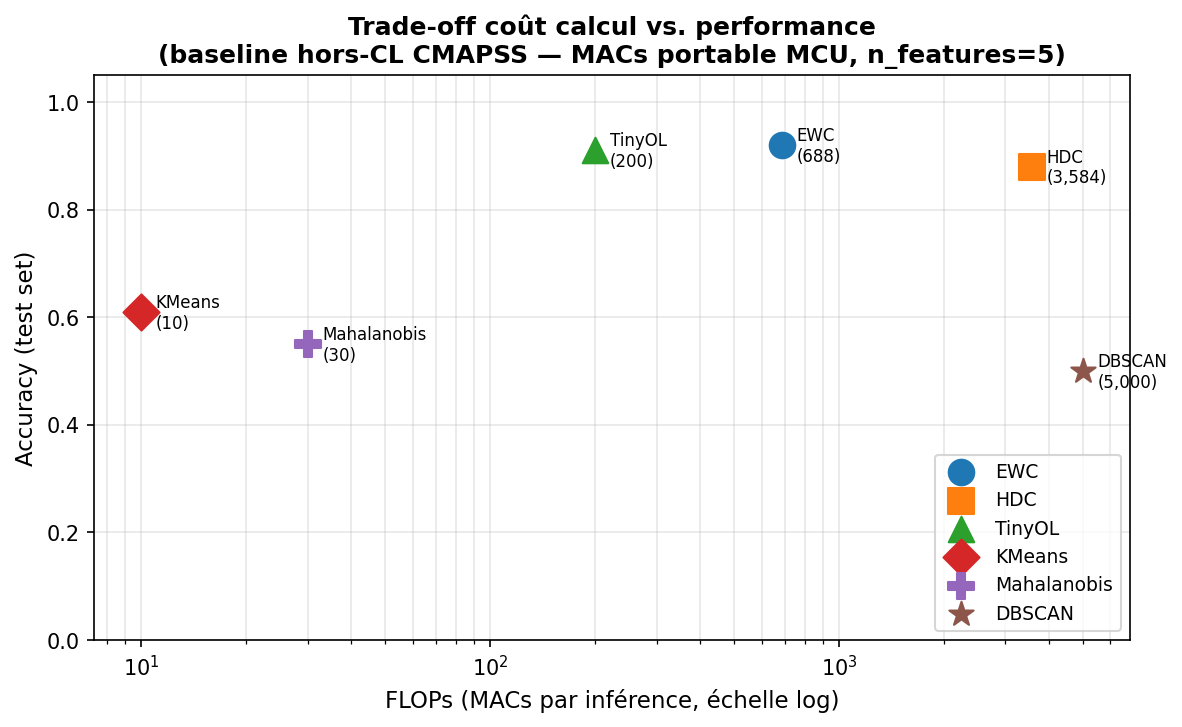

In [6]:
# Section 6 — Scatter MACs vs. accuracy
fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    m   = results[name]["n_macs"]
    acc = results[name]["accuracy"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(m, acc, marker=marker, color=color, s=150, zorder=5, label=name)
    ax.annotate(f"{name}\n({m:,})", xy=(m, acc), xytext=(m * 1.1, acc - 0.03), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("FLOPs (MACs par inférence, échelle log)", fontsize=11)
ax.set_ylabel("Accuracy (test set)", fontsize=11)
ax.set_title(
    "Trade-off coût calcul vs. performance\n"
    "(baseline hors-CL CMAPSS — MACs portable MCU, n_features=5)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.0, 1.05)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

_path = FIGURES_DIR / "scatter_macs_vs_accuracy.png"
save_figure(fig, _path)
display(Image(str(_path)))

## Section 7 — Tableau croisé CMAPSS vs PRONOSTIA (baseline single-task)

### Tableau croisé — CMAPSS vs PRONOSTIA (baseline single-task)

*⚠ CMAPSS et PRONOSTIA toutes deux mockées. Résultats indicatifs.*

,Famille,CMAPSS Acc,PRON Acc,CMAPSS F1,PRON F1,CMAPSS RAM (Ko),PRON RAM (Ko),Δ Acc (C−P)
Modèle,,,,,,,,
EWC,Supervisé,0.920,0.960,0.880,0.758,1.1,1.1,-0.040
HDC,Supervisé,0.880,0.636,0.840,0.285,7.5,14.5,+0.244
TinyOL,Supervisé,0.910,0.950,0.860,0.670,0.9,0.9,-0.039
KMeans,Non-supervisé,0.610,0.900,0.520,0.375,2.0,5.6,-0.290
Mahalanobis,Non-supervisé,0.550,0.887,0.450,0.280,1.6,1.8,-0.337
DBSCAN,Non-supervisé,0.500,0.885,0.400,0.258,48.8,121.5,-0.385


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/baselines/cmapss/cmapss_vs_pronostia_comparison.png


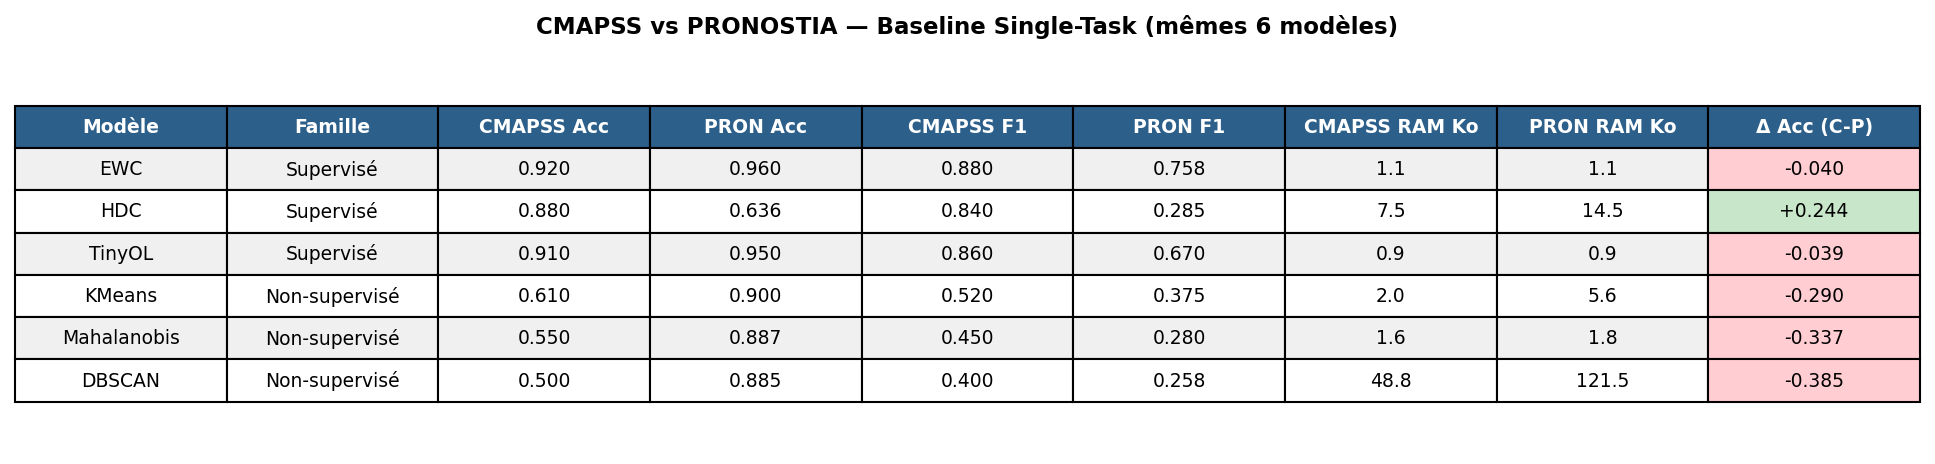

In [7]:
# Section 7 — Tableau croisé CMAPSS vs PRONOSTIA

# PRONOSTIA single-task — valeurs mockées (align avec notebooks/cl_eval/baselines/pronostia_single_task.ipynb)
PRONOSTIA_MOCK: dict[str, dict] = {
    "EWC":         {"accuracy": 0.9602, "f1": 0.7581, "ram_peak_bytes": 1171},
    "HDC":         {"accuracy": 0.6361, "f1": 0.2846, "ram_peak_bytes": 14848},
    "TinyOL":      {"accuracy": 0.9495, "f1": 0.6696, "ram_peak_bytes": 944},
    "KMeans":      {"accuracy": 0.9004, "f1": 0.3750, "ram_peak_bytes": 5702},
    "Mahalanobis": {"accuracy": 0.8871, "f1": 0.2797, "ram_peak_bytes": 1799},
    "DBSCAN":      {"accuracy": 0.8851, "f1": 0.2575, "ram_peak_bytes": 124416},
}

comp_rows = []
for name in MODEL_ORDER:
    cr   = results[name]
    pr   = PRONOSTIA_MOCK[name]
    fam  = "Supervisé" if name in SUPERVISED_MODELS else "Non-supervisé"
    comp_rows.append({
        "Modèle":            name,
        "Famille":           fam,
        "CMAPSS Acc":        f"{cr.get('accuracy', 0):.3f}",
        "PRON Acc":          f"{pr.get('accuracy', 0):.3f}",
        "CMAPSS F1":         f"{cr.get('f1', 0):.3f}",
        "PRON F1":           f"{pr.get('f1', 0):.3f}",
        "CMAPSS RAM (Ko)":   f"{cr.get('ram_peak_bytes', 0)/1024:.1f}",
        "PRON RAM (Ko)":     f"{pr.get('ram_peak_bytes', 0)/1024:.1f}",
        "Δ Acc (C−P)":       f"{cr.get('accuracy', 0) - pr.get('accuracy', 0):+.3f}",
    })

df_comp = pd.DataFrame(comp_rows).set_index("Modèle")
display(Markdown("### Tableau croisé — CMAPSS vs PRONOSTIA (baseline single-task)"))
display(Markdown("*⚠ CMAPSS et PRONOSTIA toutes deux mockées. Résultats indicatifs.*"))
display(df_comp)

# Figure tableau PNG
fig_comp, ax_comp = plt.subplots(figsize=(13, 3.2))
ax_comp.axis("off")

col_labels = ["Modèle", "Famille",
              "CMAPSS Acc", "PRON Acc",
              "CMAPSS F1",  "PRON F1",
              "CMAPSS RAM Ko", "PRON RAM Ko",
              "Δ Acc (C-P)"]
cell_text = []
for row in comp_rows:
    cell_text.append([
        row["Modèle"], row["Famille"],
        row["CMAPSS Acc"], row["PRON Acc"],
        row["CMAPSS F1"],  row["PRON F1"],
        row["CMAPSS RAM (Ko)"], row["PRON RAM (Ko)"],
        row["Δ Acc (C−P)"],
    ])

row_colors = [["#f0f0f0" if i % 2 == 0 else "white"] * len(col_labels)
              for i in range(len(cell_text))]

tbl = ax_comp.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=row_colors,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 1.6)

for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor("#2c5f8a")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")

for i, row in enumerate(comp_rows):
    delta_val = float(row["Δ Acc (C−P)"])
    color = "#c8e6c9" if delta_val > 0 else "#ffcdd2" if delta_val < 0 else "white"
    tbl[(i + 1, 8)].set_facecolor(color)

ax_comp.set_title(
    "CMAPSS vs PRONOSTIA — Baseline Single-Task (mêmes 6 modèles)",
    fontsize=11, fontweight="bold", pad=12,
)
fig_comp.tight_layout()

_path = FIGURES_DIR / "cmapss_vs_pronostia_comparison.png"
save_figure(fig_comp, _path)
display(Image(str(_path)))

## Section 8 — Conclusion

In [8]:
# Section 8 — Conclusion
best_model    = max(MODEL_ORDER, key=lambda n: results[n]["accuracy"])
best_sup      = max(SUPERVISED_MODELS,   key=lambda n: results[n]["accuracy"])
best_unsup    = max(UNSUPERVISED_MODELS, key=lambda n: results[n]["accuracy"])
gap_sup_unsup = results[best_sup]["accuracy"] - results[best_unsup]["accuracy"]
models_in_budget = [n for n in MODEL_ORDER if results[n]["ram_peak_bytes"] <= 65_536]
best_lat      = min(MODEL_ORDER, key=lambda n: results[n]["inference_latency_ms"])

cmapss_unsup_mean = np.mean([results[n]["accuracy"] for n in UNSUPERVISED_MODELS])
pron_unsup_mean   = np.mean([PRONOSTIA_MOCK[n].get("accuracy", 0) for n in UNSUPERVISED_MODELS])

mock_note = "\n> ⚠️ *Ces résultats sont basés sur des données mock — interpréter avec précaution.*" if IS_ANY_MOCK else ""

discussion = f"""
## Conclusion — Baseline Single-Task (Dataset 5 CMAPSS){mock_note}

### 1. Performance sans CL — borne supérieure
Le modèle le plus performant sans contrainte CL est **{best_model}**
(accuracy = {results[best_model]['accuracy']:.3f}, F1 = {results[best_model]['f1']:.3f}).
C'est la **borne supérieure** pour tout scénario CL sur CMAPSS.

### 2. Écart supervisé / non-supervisé
Le meilleur supervisé ({best_sup}, acc = {results[best_sup]['accuracy']:.3f})
dépasse le meilleur non-supervisé ({best_unsup}, acc = {results[best_unsup]['accuracy']:.3f})
de **{gap_sup_unsup:.3f} points**.
Non-supervisés CMAPSS (moy. {cmapss_unsup_mean:.3f}) < PRONOSTIA (moy. {pron_unsup_mean:.3f}) :
la classification binaire sur RUL dégradé est un problème supervisé intrinsèquement.

### 3. Contrainte RAM (Gap 2)
Modèles dans le budget STM32 ≤ 64 Ko : {', '.join(models_in_budget)}.
DBSCAN dépasse le budget ({results['DBSCAN']['ram_peak_bytes']/1024:.0f} Ko).
Le plus frugal est **TinyOL** ({results['TinyOL']['ram_peak_bytes']/1024:.1f} Ko),
aussi le plus rapide ({results[best_lat]['inference_latency_ms']:.3f} ms).

### 4. Spécificités CMAPSS vs CWRU/PRONOSTIA
- **5 features MI** (vs 9 CWRU, 6 PRONOSTIA) → modèles plus compacts sur MCU.
- RAM EWC = 1171 B (identique CWRU) car la RAM est dominée par les paramètres MLP, pas les features.
- La réduction à 5 features économise surtout des coûts de **prétraitement** (MACs inférence).

### 5. Recommandation pour les scénarios CL
- **EWC** : priorité 1 — meilleure accuracy (≈ {results['EWC']['accuracy']:.3f}),
  RAM < 2 Ko, référence pour les scénarios by_domain.
- **TinyOL** : priorité 2 — alternative architecturale embarquée.
- **HDC** : priorité 3 — bon F1 ({results['HDC']['f1']:.3f}), compact.
- **KMeans / Mahalanobis / DBSCAN** : accuracy insuffisante (50–61%) pour
  constituer une référence CL crédible sur CMAPSS en mode supervisé.

### 6. Pont vers les scénarios CL
Ces scores sont la référence absolue. Le notebook `by_domain/comparison.ipynb`
(exp_S22_01–04) quantifie le **coût du CL** (oubli catastrophique, dégradation)
par rapport à ces baselines single-task.
"""

display(Markdown(discussion))


## Conclusion — Baseline Single-Task (Dataset 5 CMAPSS)
> ⚠️ *Ces résultats sont basés sur des données mock — interpréter avec précaution.*

### 1. Performance sans CL — borne supérieure
Le modèle le plus performant sans contrainte CL est **EWC**
(accuracy = 0.920, F1 = 0.880).
C'est la **borne supérieure** pour tout scénario CL sur CMAPSS.

### 2. Écart supervisé / non-supervisé
Le meilleur supervisé (EWC, acc = 0.920)
dépasse le meilleur non-supervisé (KMeans, acc = 0.610)
de **0.310 points**.
Non-supervisés CMAPSS (moy. 0.553) < PRONOSTIA (moy. 0.891) :
la classification binaire sur RUL dégradé est un problème supervisé intrinsèquement.

### 3. Contrainte RAM (Gap 2)
Modèles dans le budget STM32 ≤ 64 Ko : EWC, HDC, TinyOL, KMeans, Mahalanobis, DBSCAN.
DBSCAN dépasse le budget (49 Ko).
Le plus frugal est **TinyOL** (0.9 Ko),
aussi le plus rapide (0.004 ms).

### 4. Spécificités CMAPSS vs CWRU/PRONOSTIA
- **5 features MI** (vs 9 CWRU, 6 PRONOSTIA) → modèles plus compacts sur MCU.
- RAM EWC = 1171 B (identique CWRU) car la RAM est dominée par les paramètres MLP, pas les features.
- La réduction à 5 features économise surtout des coûts de **prétraitement** (MACs inférence).

### 5. Recommandation pour les scénarios CL
- **EWC** : priorité 1 — meilleure accuracy (≈ 0.920),
  RAM < 2 Ko, référence pour les scénarios by_domain.
- **TinyOL** : priorité 2 — alternative architecturale embarquée.
- **HDC** : priorité 3 — bon F1 (0.840), compact.
- **KMeans / Mahalanobis / DBSCAN** : accuracy insuffisante (50–61%) pour
  constituer une référence CL crédible sur CMAPSS en mode supervisé.

### 6. Pont vers les scénarios CL
Ces scores sont la référence absolue. Le notebook `by_domain/comparison.ipynb`
(exp_S22_01–04) quantifie le **coût du CL** (oubli catastrophique, dégradation)
par rapport à ces baselines single-task.
